# An Intuition Builder for Regression Diagnostic Plots

Fitting a regression model is easy. Knowing whether you can *trust* it is the harder skill.

Diagnostic plots are some of the best and most widely accepted tools to build this trust. However, over the years I have noticed that instructors often gloss over these plots, as if the audience has the same intuitive understanding they do.

I developed this notebook to walk you through the plots while allowing you to interact with them, so that ***YOU* build the intuition!**

This notebook covers the **standard four-panel diagnostic set** (the same four plots R produces by
default from `plot(lm_model)`), plus a fifth check for the independence assumption that the standard
panel doesn't address:

1. **Residuals vs. Fitted** - checks linearity and homoscedasticity (constant variance)
2. **Q-Q Plot** - checks normality of residuals
3. **Scale-Location** - a dedicated, more sensitive view of homoscedasticity
4. **Residuals vs. Leverage (with Cook's distance)** - finds influential observations
5. **Residuals vs. order / ACF** - checks independence (relevant for ordered or time-series data)

For each one, we show what an **ideal** plot looks like next to plots showing **specific problems**,
so the shapes become recognizable at a glance rather than something you have to consciously reason
through every time.

**A note on what these plots do and don't tell you:** the first three check *model assumptions*.
The fourth plot is different, as it checks whether any individual data point is disproportionately
influencing your results. Both matter, but they're distinct questions, and conflating them is a
common source of confusion.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

## 1. Residuals vs. Fitted Values

After fitting a model, plot the **residuals** (actual - predicted) on the y-axis against the
**fitted values** (predicted values) on the x-axis.

**What you're looking for:** a random, formless scatter of points around the horizontal line at
zero, with no pattern in the spread and no curve. If you see structure, that structure is telling
you something specific about which assumption is broken.

We'll simulate three datasets below: one that satisfies OLS assumptions cleanly, one with
**heteroscedasticity** (non-constant variance), and one with **non-linearity** (wrong functional
form). Same sample size and base noise scale throughout, so the *shape* of the residual plot is the
only thing that differs.


In [37]:
def fit_model(X, y):
    """Fit OLS and return the fitted model object."""
    X_with_const = sm.add_constant(X)
    return sm.OLS(y, X_with_const).fit()

n = 200
x = np.linspace(0, 10, n)

# Case 1: Ideal Example
y_ideal = 3 + 2 * x + np.random.normal(0, 3, n)
model_ideal = fit_model(x, y_ideal)

# Case 2: Heteroscedasticity (variance grows with x)
y_hetero = 3 + 2 * x + np.random.normal(0, 0.3 + 0.35 * x, n)
model_hetero = fit_model(x, y_hetero)

# Case 3: Non-linearity (true relationship is quadratic, model is linear)
y_nonlin = 3 + 1.2 * x + .9 * (x - 5) ** 2 + np.random.normal(0, 3, n)
model_nonlin = fit_model(x, y_nonlin)

Before we look at the residual plots, let's first build a foundation by understanding where they come from.

We will do so by observing a more familiar plot: predicted versus actuals plots.

Below we have predicted versus actuals plots for each of the three simulated datasets: the ideal linear set, the heteroscedastic set, and the non-linear set.

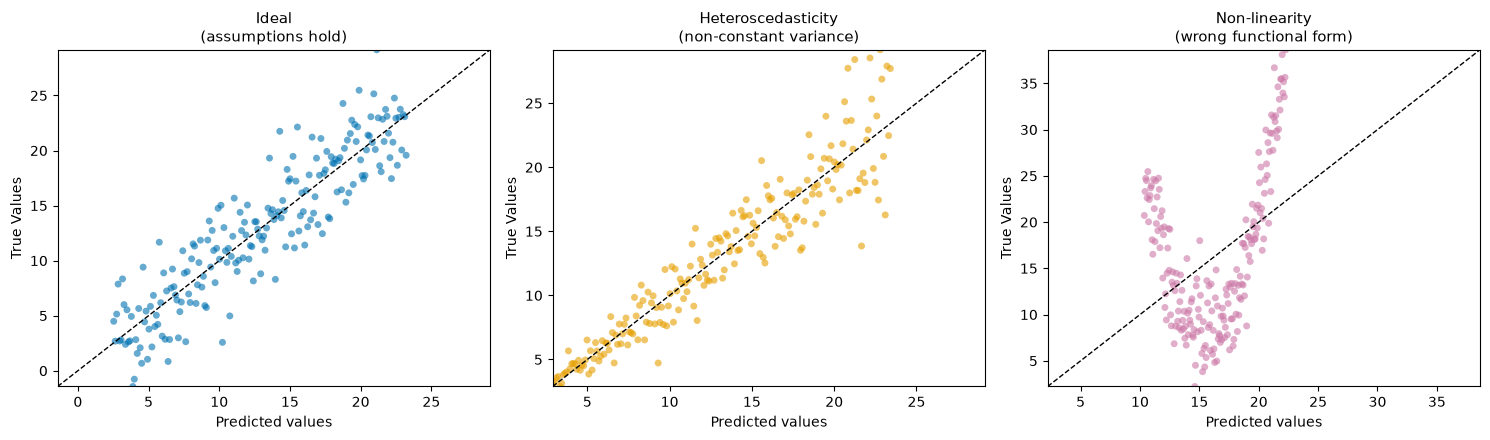

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels_1 = [
    (axes[0], model_ideal, y_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, y_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, y_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, y_true, title, color in panels_1:
    ax.scatter(model.fittedvalues, y_true, alpha=0.6, s=25, color=color, edgecolor="none")
    lims = [min(model.fittedvalues.min(), y_true.min()),max(model.fittedvalues.max(), y_true.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("True Values")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

- In the **ideal** panel, points hug the diagonal with no systematic drift.
- In the **heteroscedastic** panel, points sit close to the diagonal at low predicted values but scatter further from it as predicted values grow. 
- In the **non-linear** panel, points bow away from the diagonal in the middle of the range and pull back toward it at the edges.

Each point's vertical distance from the dashed diagonal above is exactly its residual (how far the actual value sits from the predicted value). 

Below, we plot that distance directly: the horizontal axis stays the same (still fitted values), but the vertical axis now shows actual minus predicted instead of actual. The diagonal collapses into a flat line at zero, and everything else about each point's position carries over.

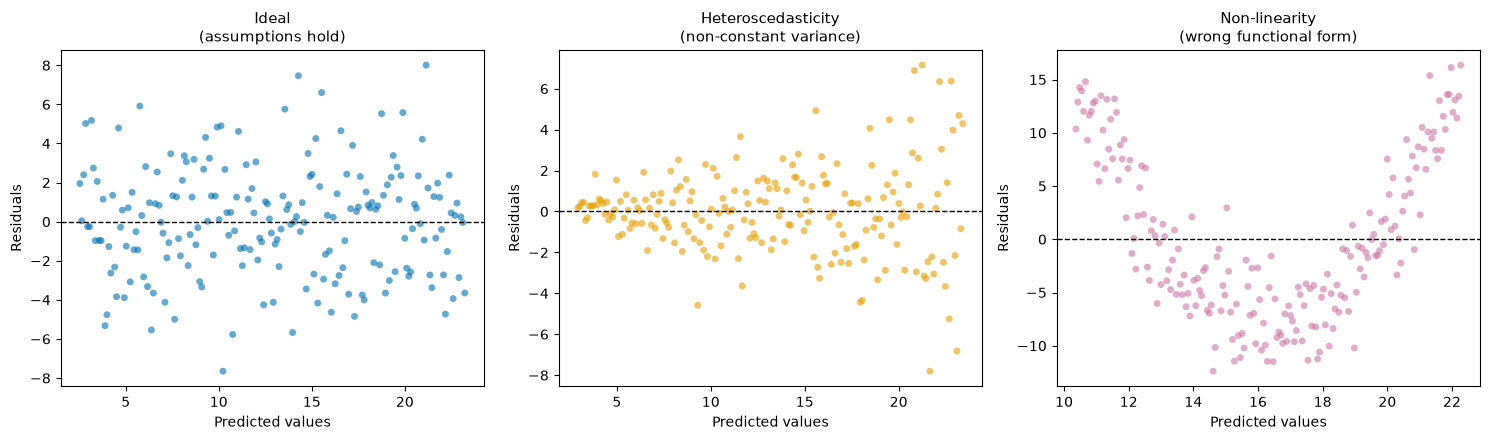

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels = [
    (axes[0], model_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, title, color in panels:
    ax.scatter(model.fittedvalues, model.resid, alpha=0.6, s=25, color=color, edgecolor="none")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Residuals")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


**Reading each panel:**

- **Ideal:** points scatter randomly above and below the zero line, with no widening and no curve. Homoscedasticity and linearity both hold.

- **Heteroscedasticity:** the *shape* is a fan. Residuals stay tight near low fitted values and spread out wider as fitted values increase. The mean of the residuals is still roughly zero everywhere (so it's *not* a linearity problem), but the **spread is not constant**, and that's the giveaway. 
Practical consequence: your standard errors (and therefore p-values and confidence intervals) become unreliable, even though the coefficient estimates themselves stay unbiased.

- **Non-linearity:** the residuals trace a visible **curve**, negative at the edges and positive in the middle (or vice versa). This means the model is systematically over- or under-predicting depending on where you are in the range of x, because the true relationship isn't a straight line. Fix: add a polynomial term, transform a variable, or reconsider the functional form.

**The distinction worth internalizing:** both patterns show up in the *same type* of plot, so it's easy to collapse "there's some pattern here" into one generic red flag. They're not the same problem, and they don't have the same fix. 

Remember:
- Heteroscedasticity is about the **spread and width** changing.
- Non-linearity is about the **center** of the residuals tracing a shape instead of sitting flat at zero.

## 2. Q-Q Plot (Normality Check)

The next assumption we need to check is **whether the residuals are normally distributed**. 

This is a genuinely
different question from the last section. Linearity and constant variance are about *where*
residuals sit and *how wide* they spread as fitted values change. Normality is about the *shape of
their distribution*, ignoring fitted values entirely.

The **Q-Q plot** is the standard tool for this, and I also found it the least intuitive plot in the
diagnostic set. So rather than open with it, we'll build up to it in three views, each one a
sharper look at the same question: *do these residuals look like they came from a normal
distribution?*

We'll carry three sets of residuals through all three views:

- **Normal** - genuinely drawn from a normal distribution
- **Right-skewed** - common with count data, spend data, or anything bounded at zero
- **Heavy-tailed** - the bulk looks normal, but extreme values show up far more often than they should

In [49]:
samp_size = 300
resid_normal = np.random.normal(0, 1, samp_size)
resid_skewed = np.random.exponential(1, samp_size) - 1
resid_heavy = stats.t.rvs(df=3, size=samp_size)

dist_specs = [
    (resid_normal, "Normal residuals", "#378ADD"),
    (resid_skewed, "Right-skewed", "#D4537E"),
    (resid_heavy, "Heavy-tailed", "#BA7517"),
]

### View 1: the histogram

The most familiar way to eyeball a distribution. We overlay a normal density curve built from each
set's own mean and standard deviation, so we're comparing shape against shape rather than against
some fixed reference.

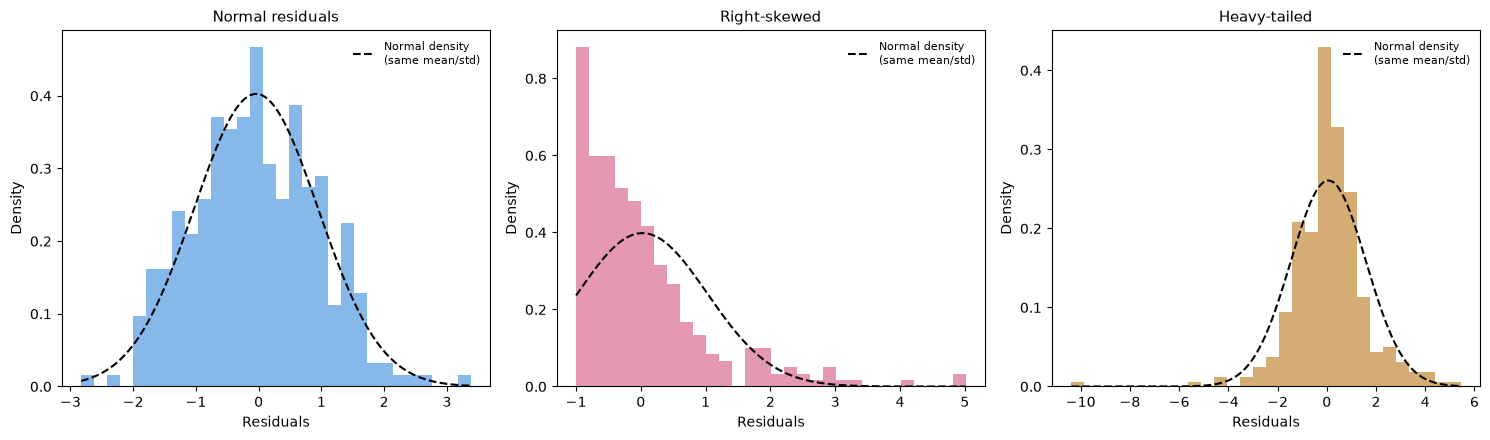

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (resid, name, color) in zip(axes, dist_specs):
    ax.hist(resid, bins=30, density=True, color=color, alpha=0.6, edgecolor="none")

    mu, sigma = np.mean(resid), np.std(resid)
    xs = np.linspace(resid.min(), resid.max(), samp_size)
    ax.plot(xs, stats.norm.pdf(xs, loc=mu, scale=sigma), color="black",
            linewidth=1.5, linestyle="--", label="Normal density\n(same mean/std)")

    ax.set_xlabel("Residuals")
    ax.set_ylabel("Density")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

Right-skewed residuals are easy to catch this way. The spike near the left edge and the long thin
tail stretching right are visible from outer space!

Heavy-tailed residuals are much trickier to catch. The bars still trace something close to a bell shape,
because only a handful of extreme points sit out past the edges, and a histogram bins residuals together, so
those rare points barely dent the overall picture. That's the blind spot worth remembering: **a
distribution can look normal in a histogram while still failing normality in ways that matter for
inference.**

A histogram checks the shape at a glance, but it obscures individual points once they're grouped into bins. 
The next view maintains visibility of every data point.

### View 2: sorted residuals, rank by rank

Since binning is exactly what let those heavy-tail outliers hide in the histogram, the next view drops bins entirely and checks every single residual on its own, one rank at a time, against what normality would predict there. 

How: we sort the residuals from smallest to largest, so each one gets a rank from 1 to 300. The x-axis is that rank; the y-axis is the residual value sitting at it, sorted low to high. We then place, at every one of those same ranks, the value a normal distribution would have produced there. 

Two lines, same x-axis, each rank checked on its own rather than swept into a bin.

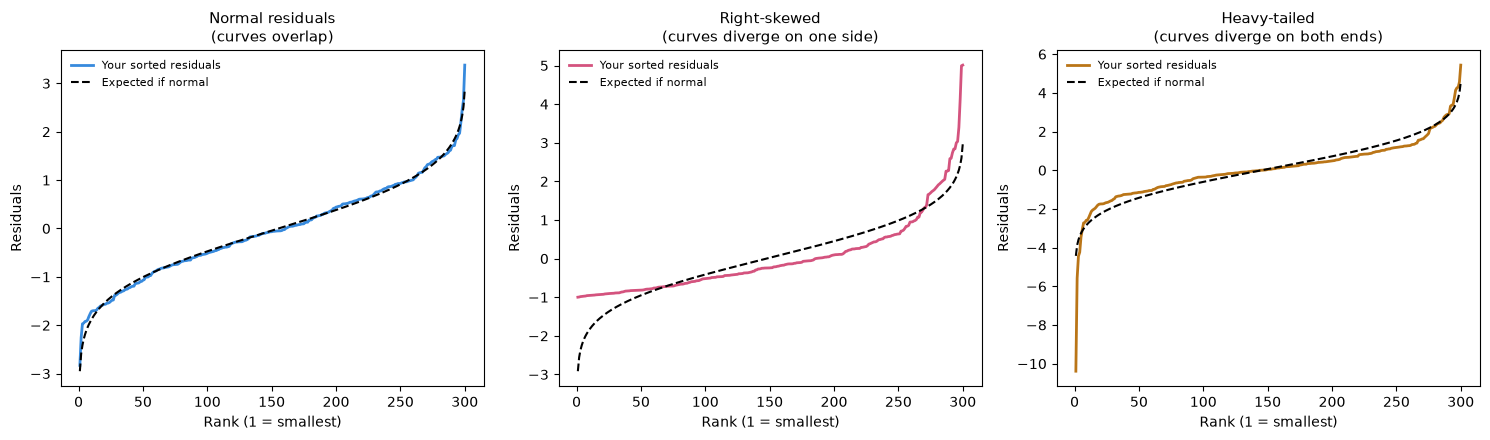

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

notes = ["curves overlap", "curves diverge on one side", "curves diverge on both ends"]

for ax, (resid, name, color), note in zip(axes, dist_specs, notes):
    n = len(resid)
    ranks = np.arange(1, n + 1)
    sorted_resid = np.sort(resid)

    probs = (ranks - 0.5) / n
    theoretical = stats.norm.ppf(probs, loc=np.mean(resid), scale=np.std(resid))

    ax.plot(ranks, sorted_resid, color=color, linewidth=2, label="Your sorted residuals")
    ax.plot(ranks, theoretical, color="black", linewidth=1.5, linestyle="--",
            label="Expected if normal")
    ax.set_xlabel("Rank (1 = smallest)")
    ax.set_ylabel("Residuals")
    ax.set_title(f"{name}\n({note})", fontsize=11)
    ax.legend(fontsize=8, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

Now the differences are unmistakable, including the one the histogram missed.

- **Normal:** the two lines sit on top of each other from rank 1 to rank 300.
- **Right-skewed:** the lines track closely through the middle ranks, then the colored line climbs
  far above the dashed one at the top ranks. One tail pulling away.
- **Heavy-tailed:** *both* ends pull away while the middle still tracks closely. The lowest ranks
  run below what normality predicts and the highest ranks run above it.

### View 3: the Q-Q plot

Before the plot itself, one piece of vocabulary, since the axis labels don't mean much without it.

**A quantile is a cut point in sorted data.** Line up all your values from smallest to largest. The
25th percentile is the value where a quarter of the data sits below it. The median is the 50th.
That's the whole idea: a quantile answers *"what value sits at this position in the sorted lineup?"*

That's exactly what View 2 was already showing, one rank at a time. A Q-Q plot takes the same two
sequences and pairs them differently.

**Every dot on a Q-Q plot is one quantile.** At that quantile we have two numbers: the residual
value we actually observed there, and the residual value a normal distribution would have produced
there. The dot's position *is* those two numbers.

- **The horizontal axis is the theoretical value:** if these residuals were perfectly normal, this
  is the value we'd expect at this quantile.
- **The vertical axis is the observed value:** what our residuals actually did at that same quantile.

Concretely: say at rank 250 out of 300, the observed residual is 1.2 and a normal distribution would
have produced 0.9. In View 2, that's two points at x = 250, one at height 1.2 and one at height 0.9,
with a small gap between them. In the Q-Q plot, that same rank collapses into a single dot at
(0.9, 1.2). Nothing new is computed. The same two sequences are just plotted against each other
instead of both against rank.

**So a dot on the diagonal means the observed value matched the normal expectation exactly at that
quantile.** Points hugging the line all the way along means the residuals match a normal
distribution across the whole range, center *and* tails.

One thing worth flagging: this diagonal looks identical to the one in the predicted-vs-actual plot
back in Section 1, but it answers a different question. There, the diagonal meant *prediction equals
reality* for an individual observation. Here, it means *the observed residual at this quantile equals
what normality predicts*. Same visual device, unrelated claims.

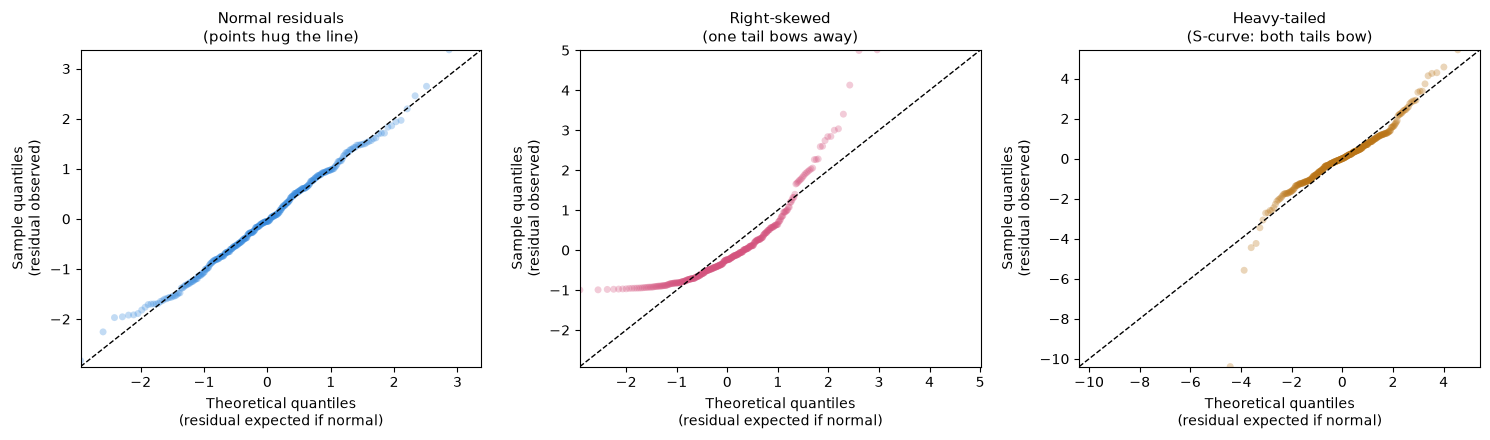

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

qq_notes = ["points hug the line", "one tail bows away", "S-curve: both tails bow"]

for ax, (resid, name, color), note in zip(axes, dist_specs, qq_notes):
    n = len(resid)
    probs = (np.arange(1, n + 1) - 0.5) / n

    # Theoretical quantiles scaled to the residuals' own mean and spread, so both axes
    # stay in raw residual units and the diagonal is a true y = x reference line.
    theoretical = stats.norm.ppf(probs, loc=np.mean(resid), scale=np.std(resid))
    observed = np.sort(resid)

    ax.scatter(theoretical, observed, alpha=0.3, s=25, color=color, edgecolor="none")

    lims = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Theoretical quantiles\n(residual expected if normal)")
    ax.set_ylabel("Sample quantiles\n(residual observed)")
    ax.set_title(f"{name}\n({note})", fontsize=11)

plt.tight_layout()
plt.show()

**Reading each panel:**

- **Normal:** dots sit almost on top of the diagonal from one end to the other. Observed matches
  expected at essentially every quantile.

- **Right-skewed:** the whole curve bows *above* the diagonal, convex from end to end, for two
  different reasons at the two ends. At the **low** end, the observed residuals sit above what
  normality predicts, because this distribution is bounded below (an exponential shifted to center
  at zero can't go below -1), so there's nothing out there to match the long left tail a normal
  distribution expects. At the **high** end, they climb above the line again, this time because the
  right tail genuinely runs longer than normal. Both departures point the same direction on the
  page, which is the signature of skew rather than heavy tails.

- **Heavy-tailed:** the signature **S-curve**. Dots sit below the line at the low end and above it at
  the high end, both tails bowing away while the middle quantiles stay close. Note that this is the
  case the histogram waved through as roughly normal.

**Reading the direction of a departure:** a dot **above** the line means the observed residual is
larger than normality predicts at that quantile; **below** means smaller. That gives you a quick
two-case rule:

- **Below on the left, above on the right** (the S-curve) means more extreme values than normal in
  *both* directions. That's heavy tails.
- **Above on both ends** (a convex bow) means the distribution is stretched toward the high end and
  compressed at the low end. That's right skew. A concave bow, below on both ends, is left skew.

**A note for when you use this in practice:** most libraries, including `statsmodels`'
`sm.qqplot()`, standardize the axes by default, so the ticks read in standard deviations rather than
raw residual units. We built this by hand so both axes stay in the residuals' own units, which makes
the diagonal mean exactly what's described above. The *shape* is identical either way, since
standardizing rescales both axes by the same amount, and the shape is the whole point.

## 3. Scale-Location Plot
placeholder

## 4. Residuals vs. Leverage (and Cook's Distance)
placeholder

## 5. Independence: Residuals vs. Order (and the ACF)
placeholder